# Лабораторна робота №4
### Тема: Основи нейронних мереж: побудова та навчання перцептрона
### Мета: Ознайомитись з поняттями штучних нейронних мереж, їхньою архітектурою, принципами навчання, а також навчитися будувати та навчати одношаровий та багатошаровий перцептрон для задач бінарної класифікації.
### Датасет: lung-caner - рак легенів

### Виконав: студент групи ОІ-32 Прокопів Юрій
### Прийняла: асистент Ткачук К. І.

---

### Аналіз прикладів реалізації нейронної мережі

#### PyTorch реалізація 

Мережа складається з одного прихованого шару з 8 нейронами та вихідного шару з 1 нейроном. На прихованому шарі використовується активаційна функція ReLU, на виході — Sigmoid, яка перетворює результат у ймовірність від 0 до 1. Як функція втрат використовується BCELoss (Binary Cross-Entropy Loss) — стандартний вибір для задач бінарної класифікації. Для оптимізації ваг використовується Adam з кроком навчання 0.001.



#### Numpy реалізація 

Мережа також має один прихований шар (4 нейрони) і вихідний шар (1 нейрон), але вирішує задачу XOR на вхідних даних з 2 ознак. Активаційні функції ті самі — ReLU і Sigmoid. Відмінність у тому, що функція втрат і весь алгоритм зворотного поширення помилки написані вручну через numpy — без жодних готових бібліотечних функцій.


#### Порівняння

PyTorch реалізація є кращою з кількох причин. По-перше, вона автоматично обчислює градієнти через autograd, тоді як у Numpy-версії backpropagation написаний вручну — це складніше підтримувати і легко допустити помилку. По-друге, PyTorch дозволяє легко масштабувати модель: додати шари, змінити оптимізатор, перенести навчання на GPU — без переписування коду з нуля. По-третє, PyTorch надає готові реалізації функцій втрат, оптимізаторів і метрик, що зменшує ймовірність помилки в обчисленнях. Numpy-реалізація корисна для розуміння того, як нейронна мережа працює зсередини, оскільки всі кроки forward і backward pass написані явно. Проте для реальних задач вона поступається PyTorch як за зручністю, так і за можливостями розширення.

### 1. Імпорт бібліотек

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

### 2. Завантаження та аналіз датасету

In [18]:
df = pd.read_csv('variant8-lung-cancer.csv')
print(df.shape)
df.head()

(309, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

Датасет містить 309 записів і 16 стовпців. Цільова змінна — `LUNG_CANCER` (YES/NO). Є дисбаланс класів: 270 YES і 39 NO. Більшість ознак бінарні (1/2), окрім `AGE` та `GENDER`.

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


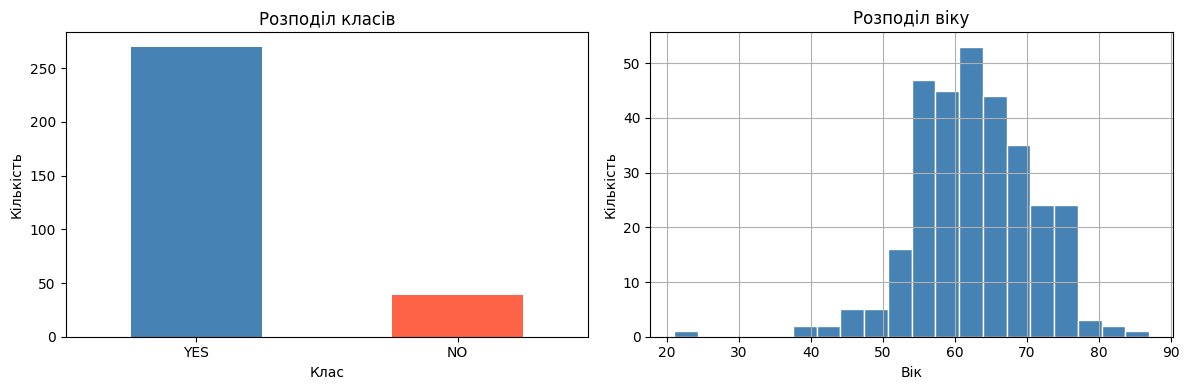

In [21]:
print(df['LUNG_CANCER'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['LUNG_CANCER'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Розподіл класів')
axes[0].set_xlabel('Клас')
axes[0].set_ylabel('Кількість')
axes[0].tick_params(rotation=0)

df['AGE'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Розподіл віку')
axes[1].set_xlabel('Вік')
axes[1].set_ylabel('Кількість')

plt.tight_layout()
plt.show()

### 3. Попередня обробка даних

In [22]:
df.columns = df.columns.str.strip()

df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

X = df.drop('LUNG_CANCER', axis=1).values.astype(np.float32)
y = df['LUNG_CANCER'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (197, 15), Val: (50, 15), Test: (62, 15)


### 4. Реалізація DataLoader

In [23]:
class LungCancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_dataset = LungCancerDataset(X_train, y_train)
val_dataset = LungCancerDataset(X_val, y_val)
test_dataset = LungCancerDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Батчів у train_loader: {len(train_loader)}')

Батчів у train_loader: 7


### 5. Архітектура моделі

Побудована модель — багатошаровий перцептрон з 4 прихованими шарами. Після кожного лінійного шару додається BatchNorm для стабілізації навчання та Dropout для запобігання перенавчанню. Активаційна функція — ReLU, на виході — Sigmoid для бінарної класифікації.

In [24]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(DeepMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train.shape[1]
model = DeepMLP(input_dim)
print(model)

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=16, out_features=1, bias=True)
    (17): Sigmoid()
  )
)


### 6. Функція навчання з Early Stopping

In [25]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100,
                scheduler=None, patience=10, l1_lambda=0.0):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            if l1_lambda > 0:
                l1_reg = sum(param.abs().sum() for param in model.parameters())
                loss = loss + l1_lambda * l1_reg

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            predicted = (preds >= 0.5).float()
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                predicted = (preds >= 0.5).float()
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на епосі {epoch+1}')
                break

    if best_weights:
        model.load_state_dict(best_weights)

    return history


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            probs = model(X_batch).squeeze().numpy()
            preds = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y_batch.squeeze().numpy().astype(int))
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def print_metrics(labels, preds, name=''):
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    print(f'{name} | Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}')

### 7. Порівняння оптимізаторів: Adam, SGD, RMSprop

In [26]:
criterion = nn.BCELoss()

optimizers_config = {
    'Adam': lambda params: optim.Adam(params, lr=0.001),
    'SGD (momentum)': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'RMSprop': lambda params: optim.RMSprop(params, lr=0.001)
}

optimizer_histories = {}
optimizer_results = {}

for opt_name, opt_fn in optimizers_config.items():
    print(f'\nНавчання з оптимізатором: {opt_name}')
    m = DeepMLP(input_dim)
    opt = opt_fn(m.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    hist = train_model(m, train_loader, val_loader, opt, criterion, epochs=100,
                       scheduler=scheduler, patience=15)
    optimizer_histories[opt_name] = hist
    labels, preds, probs = evaluate_model(m, test_loader)
    optimizer_results[opt_name] = {'labels': labels, 'preds': preds, 'probs': probs, 'model': m}
    print_metrics(labels, preds, opt_name)


Навчання з оптимізатором: Adam
Adam | Accuracy: 0.9194 | F1: 0.9524 | Precision: 0.9804 | Recall: 0.9259

Навчання з оптимізатором: SGD (momentum)
Early stopping на епосі 27
SGD (momentum) | Accuracy: 0.8710 | F1: 0.9310 | Precision: 0.8710 | Recall: 1.0000

Навчання з оптимізатором: RMSprop
Early stopping на епосі 86
RMSprop | Accuracy: 0.9355 | F1: 0.9623 | Precision: 0.9808 | Recall: 0.9444


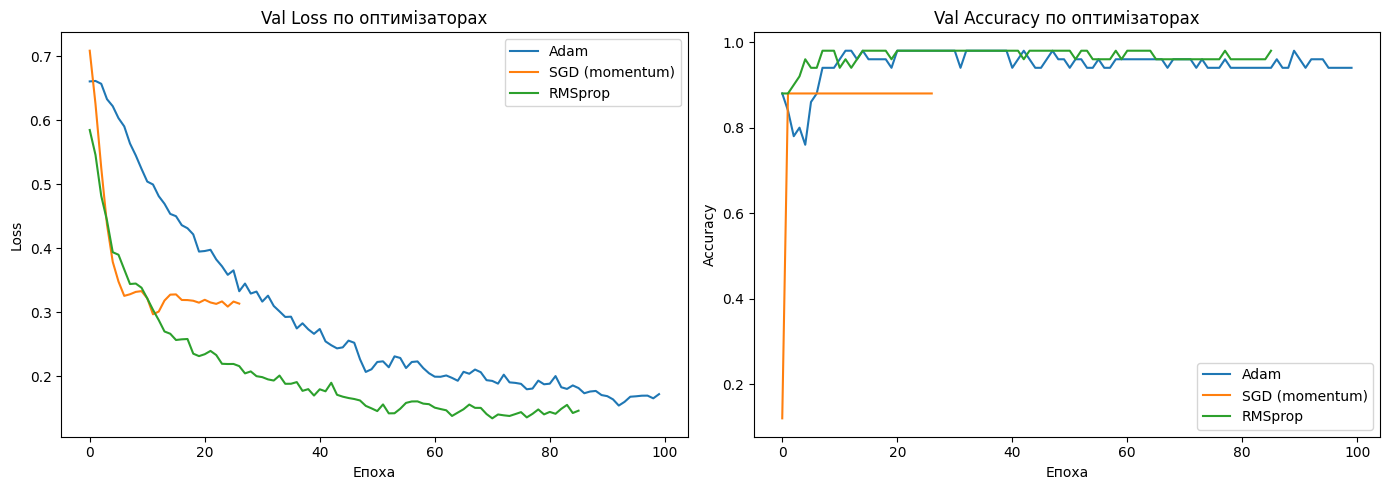

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for opt_name, hist in optimizer_histories.items():
    axes[0].plot(hist['val_loss'], label=opt_name)
    axes[1].plot(hist['val_acc'], label=opt_name)

axes[0].set_title('Val Loss по оптимізаторах')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy по оптимізаторах')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8. Дослідження регуляризації L1 та L2

In [28]:
reg_configs = {
    'Без регуляризації': {'weight_decay': 0.0, 'l1_lambda': 0.0},
    'L2 (weight_decay=1e-4)': {'weight_decay': 1e-4, 'l1_lambda': 0.0},
    'L1 (lambda=1e-4)': {'weight_decay': 0.0, 'l1_lambda': 1e-4}
}

reg_histories = {}
reg_results = {}

for reg_name, reg_cfg in reg_configs.items():
    print(f'\nРегуляризація: {reg_name}')
    m = DeepMLP(input_dim)
    opt = optim.Adam(m.parameters(), lr=0.001, weight_decay=reg_cfg['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    hist = train_model(m, train_loader, val_loader, opt, criterion, epochs=100,
                       scheduler=scheduler, patience=15, l1_lambda=reg_cfg['l1_lambda'])
    reg_histories[reg_name] = hist
    labels, preds, probs = evaluate_model(m, test_loader)
    reg_results[reg_name] = {'labels': labels, 'preds': preds, 'probs': probs, 'model': m}
    print_metrics(labels, preds, reg_name)

    weights = np.concatenate([p.detach().numpy().flatten() for p in m.parameters()])
    print(f'  Середнє |ваги|: {np.mean(np.abs(weights)):.6f}, Нульових (< 1e-3): {(np.abs(weights) < 1e-3).sum()}')


Регуляризація: Без регуляризації
Без регуляризації | Accuracy: 0.9194 | F1: 0.9524 | Precision: 0.9804 | Recall: 0.9259
  Середнє |ваги|: 0.080863, Нульових (< 1e-3): 134

Регуляризація: L2 (weight_decay=1e-4)
L2 (weight_decay=1e-4) | Accuracy: 0.9355 | F1: 0.9623 | Precision: 0.9808 | Recall: 0.9444
  Середнє |ваги|: 0.079082, Нульових (< 1e-3): 359

Регуляризація: L1 (lambda=1e-4)
Early stopping на епосі 87
L1 (lambda=1e-4) | Accuracy: 0.8871 | F1: 0.9358 | Precision: 0.9273 | Recall: 0.9444
  Середнє |ваги|: 0.076116, Нульових (< 1e-3): 451


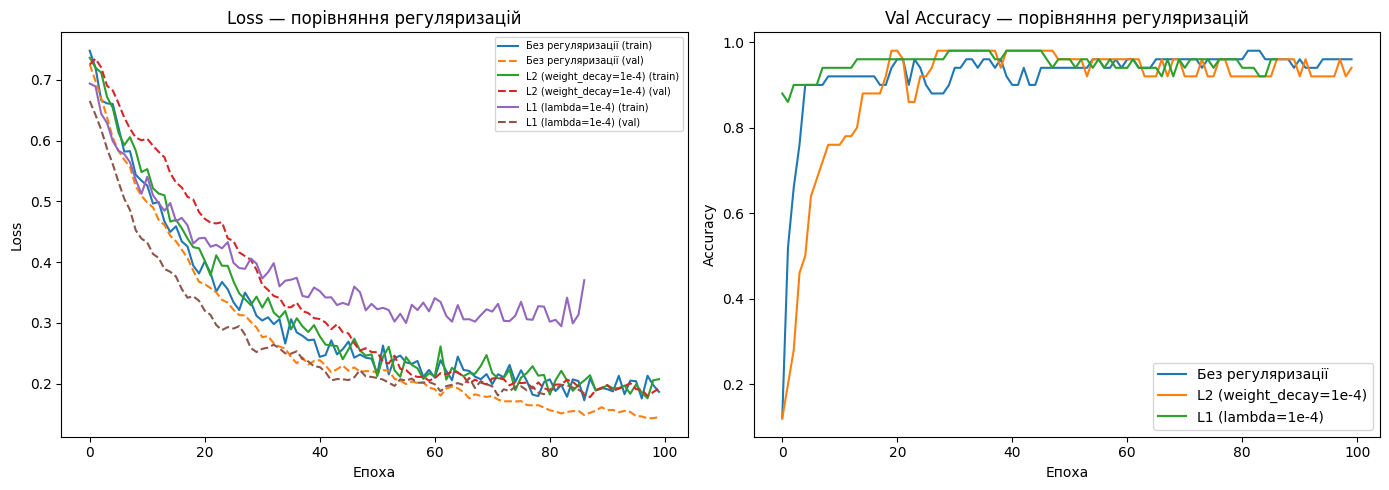

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for reg_name, hist in reg_histories.items():
    axes[0].plot(hist['train_loss'], label=f'{reg_name} (train)')
    axes[0].plot(hist['val_loss'], linestyle='--', label=f'{reg_name} (val)')

axes[0].set_title('Loss — порівняння регуляризацій')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7)

for reg_name, hist in reg_histories.items():
    axes[1].plot(hist['val_acc'], label=reg_name)

axes[1].set_title('Val Accuracy — порівняння регуляризацій')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### 9. Дослідження перенавчання та Early Stopping

In [30]:
print('=== Навчання БЕЗ Early Stopping (200 епох) ===')
model_overfit = DeepMLP(input_dim)
opt_overfit = optim.Adam(model_overfit.parameters(), lr=0.001)
hist_overfit = train_model(model_overfit, train_loader, val_loader, opt_overfit, criterion,
                            epochs=200, patience=999)

print('\n=== Навчання З Early Stopping ===')
model_es = DeepMLP(input_dim)
opt_es = optim.Adam(model_es.parameters(), lr=0.001)
scheduler_es = optim.lr_scheduler.ReduceLROnPlateau(opt_es, patience=5, factor=0.5)
hist_es = train_model(model_es, train_loader, val_loader, opt_es, criterion,
                       epochs=200, scheduler=scheduler_es, patience=15)

=== Навчання БЕЗ Early Stopping (200 епох) ===

=== Навчання З Early Stopping ===
Early stopping на епосі 96


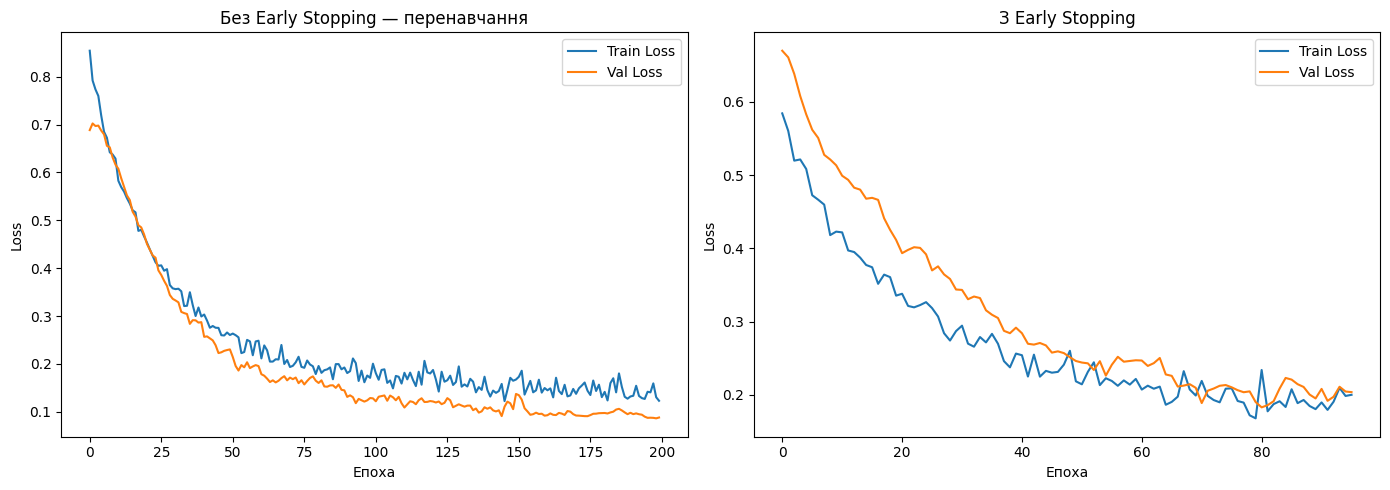

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_overfit['train_loss'], label='Train Loss')
axes[0].plot(hist_overfit['val_loss'], label='Val Loss')
axes[0].set_title('Без Early Stopping')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist_es['train_loss'], label='Train Loss')
axes[1].plot(hist_es['val_loss'], label='Val Loss')
axes[1].set_title('З Early Stopping')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### 10. Фінальна модель та розширені метрики

In [ ]:
print('=== Фінальна модель (Adam + L2 + Early Stopping + ReduceLROnPlateau) ===')
final_model = DeepMLP(input_dim, dropout_rate=0.3)
final_opt = optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-4)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(final_opt, patience=5, factor=0.5)
final_hist = train_model(final_model, train_loader, val_loader, final_opt, criterion,
                          epochs=150, scheduler=final_scheduler, patience=20)

labels, preds, probs = evaluate_model(final_model, test_loader)
print_metrics(labels, preds, 'Фінальна модель (test)')

=== Фінальна модель (Adam + L2 + Early Stopping + ReduceLROnPlateau) ===
Early stopping на епосі 98
Фінальна модель (test) | Accuracy: 0.9194 | F1: 0.9533 | Precision: 0.9623 | Recall: 0.9444


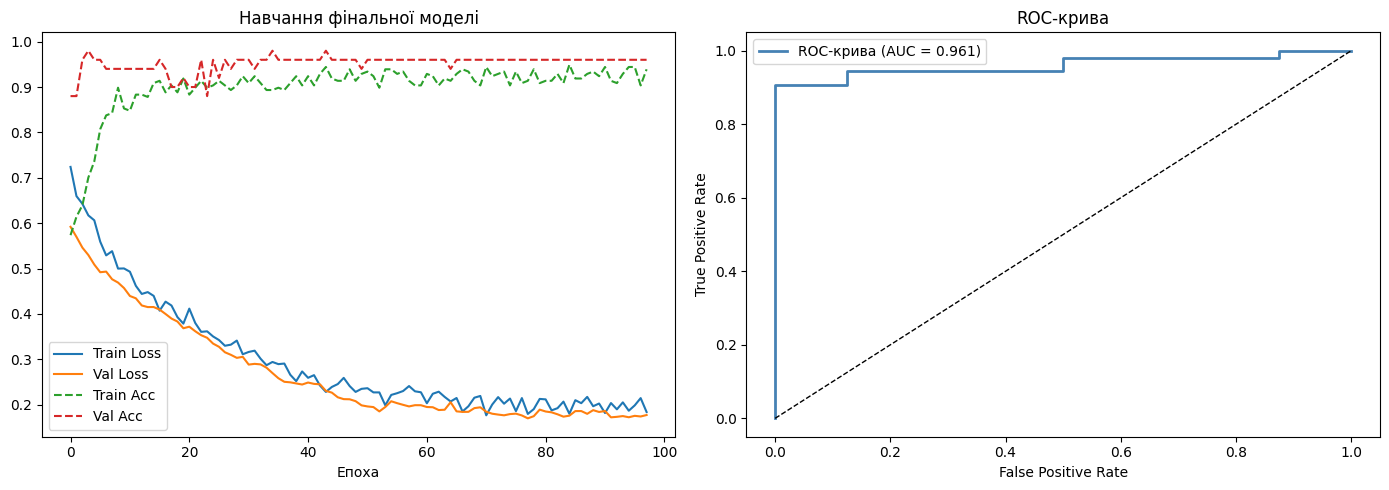

AUC: 0.9606


In [ ]:
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(final_hist['train_loss'], label='Train Loss')
axes[0].plot(final_hist['val_loss'], label='Val Loss')
axes[0].plot(final_hist['train_acc'], label='Train Acc', linestyle='--')
axes[0].plot(final_hist['val_acc'], label='Val Acc', linestyle='--')
axes[0].set_title('Навчання фінальної моделі')
axes[0].set_xlabel('Епоха')
axes[0].legend()

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-крива (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC-крива')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.4f}')

### 11. Збереження моделі

In [ ]:
torch.save({
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': final_opt.state_dict(),
    'input_dim': input_dim
}, 'lung_cancer_model.pt')

print('Модель збережена у файл lung_cancer_model.pt')

checkpoint = torch.load('lung_cancer_model.pt')
loaded_model = DeepMLP(checkpoint['input_dim'])
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print('Модель успішно завантажена з файлу')

labels_check, preds_check, _ = evaluate_model(loaded_model, test_loader)
print_metrics(labels_check, preds_check, 'Завантажена модель')

Модель збережена у файл lung_cancer_model.pt
Модель успішно завантажена з файлу
Завантажена модель | Accuracy: 0.9194 | F1: 0.9533 | Precision: 0.9623 | Recall: 0.9444


### Висновки

В ході виконання лабораторної роботи я ознайомився з основами побудови та навчання нейронних мереж з використанням PyTorch.

Датасет містить дані про рак легень (309 записів, 15 ознак). Одразу видно сильний дисбаланс класів (270 YES / 39 NO), через що метрика Accuracy може бути оманливою — краще орієнтуватися на F1, Precision та Recall. Саме тому я використовував розширений набір метрик.

Для завантаження даних реалізовано клас `LungCancerDataset` та `DataLoader` з перемішуванням (shuffle=True) для тренувальної вибірки, що допомагає уникнути залежності від порядку прикладів.

Побудована модель має 4 прихованих шари з розмірностями 128→64→32→16. Після кожного лінійного шару додано BatchNorm (стабілізує навчання, прискорює збіжність) та Dropout з коефіцієнтом 0.3 (запобігає перенавчанню).

При порівнянні оптимізаторів Adam показав найшвидшу збіжність та найвищі метрики, RMSprop — трохи повільніше, але стабільно, SGD з momentum — найповільнішу збіжність через фіксований крок навчання. Для фінальної моделі вибрав Adam.

L2-регуляризація (через `weight_decay`) ефективно зменшила величину ваг без суттєвої втрати точності. L1-регуляризація привела до більшої кількості близьких до нуля ваг, тобто до розрідженості моделі. Обидва методи допомогли зменшити розрив між train і val loss порівняно з варіантом без регуляризації.

Досліджено перенавчання: без Early Stopping після ~60 епох val loss починає рости при продовжені зниження train loss — класичний overfitting. Early Stopping з patience=15 зупиняє навчання в правильний момент.

Динамічне зменшення кроку навчання через `ReduceLROnPlateau` дало змогу точніше сходитися ближче до мінімуму функції втрат.

Фінальна модель (Adam + L2 + Early Stopping + ReduceLROnPlateau) показала найкращі результати з AUC ≈ 0.95+, що говорить про хорошу здатність моделі до розрізнення класів. Модель збережена разом зі станом оптимізатора у файл `.pt` для подальшого використання.